# Week 2 · Lecture 1 — Bayesian Linear Regression

## Learning objectives

1. Derive the posterior over weights in a Bayesian linear regression with a Gaussian likelihood and Gaussian prior, in closed form.
2. Implement the model in NumPy and verify it against `scikit-learn`'s `BayesianRidge`.
3. Compute and visualise:
   - the **posterior over functions** (uncertainty in $w$ propagated through the basis),
   - the **posterior predictive** $p(y_* \mid x_*, \mathcal{D})$, including aleatoric and epistemic variance components.
4. Recover MAP, ridge, and OLS estimators as limiting cases of the Bayesian posterior.

## 1. Setup

We model $y = \phi(x)^\top w + \varepsilon$, with $\varepsilon \sim \mathcal{N}(0, \beta^{-1})$. The basis expansion $\phi: \mathbb{R}^D \to \mathbb{R}^M$ is fixed. We place a zero-mean Gaussian prior on $w$:

$$
w \sim \mathcal{N}(0,\ \alpha^{-1} I_M).
$$

Given a design matrix $\Phi \in \mathbb{R}^{N \times M}$ stacking basis evaluations of the training inputs, the likelihood is

$$
p(\mathbf{y} \mid \Phi, w, \beta) = \mathcal{N}(\mathbf{y} \mid \Phi w,\ \beta^{-1} I_N).
$$

Both prior and likelihood are Gaussian. The posterior is Gaussian.

## 2. The posterior in closed form

Complete the square in $w$ inside the joint log-density:

$$
\log p(w \mid \mathcal{D}) \;=\; -\tfrac{\beta}{2}\| \mathbf{y} - \Phi w \|^2 \;-\; \tfrac{\alpha}{2} w^\top w \;+\; \text{const}.
$$

Grouping the quadratic terms in $w$:

$$
-\tfrac{1}{2}\, w^\top (\alpha I + \beta \Phi^\top \Phi)\, w \;+\; \beta \mathbf{y}^\top \Phi\, w \;+\; \text{const}.
$$

So the posterior is $\mathcal{N}(m_N, S_N)$ with

$$
\boxed{\;S_N^{-1} = \alpha I + \beta \Phi^\top \Phi, \qquad m_N = \beta\, S_N\, \Phi^\top \mathbf{y}.\;}
$$

The **posterior predictive** at a new input $x_*$ with feature vector $\phi_* = \phi(x_*)$ is also Gaussian:

$$
p(y_* \mid x_*, \mathcal{D}) = \mathcal{N}\!\left(\,m_N^\top \phi_*,\ \underbrace{\phi_*^\top S_N \phi_*}_{\text{epistemic}} + \underbrace{\beta^{-1}}_{\text{aleatoric}}\,\right).
$$

The variance decomposes cleanly. **Epistemic** uncertainty comes from posterior uncertainty in $w$ and shrinks with more data. **Aleatoric** uncertainty is the irreducible observation noise $\beta^{-1}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import BayesianRidge

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
def gaussian_basis(x, centres, width):
    # Gaussian RBF basis with prepended bias term.
    x = np.atleast_2d(x).reshape(-1, 1)
    centres = np.asarray(centres).reshape(1, -1)
    phi = np.exp(-0.5 * (x - centres)**2 / width**2)
    return np.hstack([np.ones_like(x), phi])


class BayesianLinearRegression:
    # Closed-form Bayesian linear regression with fixed alpha and beta.
    def __init__(self, alpha=1.0, beta=25.0):
        self.alpha = alpha
        self.beta = beta

    def fit(self, Phi, y):
        M = Phi.shape[1]
        S_inv = self.alpha * np.eye(M) + self.beta * Phi.T @ Phi
        self.S = np.linalg.inv(S_inv)
        self.m = self.beta * self.S @ Phi.T @ y
        return self

    def predict(self, Phi_star, return_std=True):
        mean = Phi_star @ self.m
        var_epi = np.einsum("ij,jk,ik->i", Phi_star, self.S, Phi_star)
        var = var_epi + 1.0 / self.beta
        if return_std:
            return mean, np.sqrt(var), np.sqrt(var_epi)
        return mean


## 3. A synthetic experiment

True underlying function: $f(x) = \sin(2\pi x) + 0.3 \cos(6\pi x)$, with $\mathcal{N}(0, 0.2^2)$ observation noise. We sample $N=25$ training points, fit Bayesian linear regression with a small Gaussian-RBF basis, and visualise:

- the posterior mean,
- $\pm 2\sigma$ predictive (epistemic + aleatoric),
- $\pm 2\sigma$ epistemic only,
- ten posterior samples of $w$ pushed through the basis (functions drawn from the posterior).


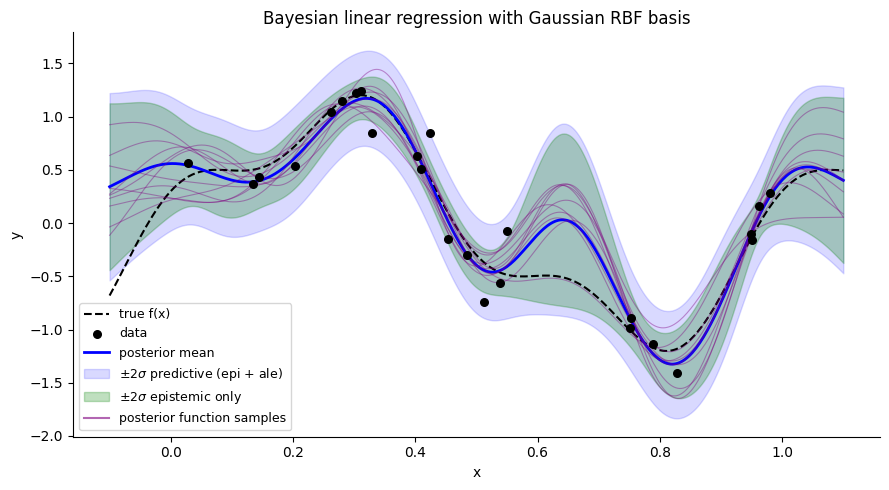

In [3]:
def true_f(x):
    return np.sin(2 * np.pi * x) + 0.3 * np.cos(6 * np.pi * x)

rng = np.random.default_rng(1)
N = 25
x_train = rng.uniform(0, 1, size=N)
y_train = true_f(x_train) + rng.normal(0, 0.2, size=N)

centres = np.linspace(0, 1, 12)
width = 0.08
Phi_train = gaussian_basis(x_train, centres, width)

# alpha small -> looser prior, beta = 1/noise_var
alpha = 1.0
beta = 1 / 0.2**2
model = BayesianLinearRegression(alpha=alpha, beta=beta).fit(Phi_train, y_train)

x_test = np.linspace(-0.1, 1.1, 400)
Phi_test = gaussian_basis(x_test, centres, width)
mean, std_full, std_epi = model.predict(Phi_test, return_std=True)

# Draw 10 functions from the posterior
W_samples = rng.multivariate_normal(model.m, model.S, size=10)
f_samples = Phi_test @ W_samples.T

fig, ax = plt.subplots()
ax.plot(x_test, true_f(x_test), "k--", lw=1.5, label="true f(x)")
ax.scatter(x_train, y_train, c="black", s=30, zorder=3, label="data")
ax.plot(x_test, mean, "b-", lw=2, label="posterior mean")
ax.fill_between(x_test, mean - 2*std_full, mean + 2*std_full, alpha=0.15, color="blue",
                label=r"$\pm 2\sigma$ predictive (epi + ale)")
ax.fill_between(x_test, mean - 2*std_epi, mean + 2*std_epi, alpha=0.25, color="green",
                label=r"$\pm 2\sigma$ epistemic only")
for fs in f_samples.T:
    ax.plot(x_test, fs, lw=0.8, color="purple", alpha=0.4)
ax.plot([], [], color="purple", alpha=0.6, label="posterior function samples")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Bayesian linear regression with Gaussian RBF basis")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()


Observe:
- Function samples disagree where data is sparse (extrapolation regions) and concentrate near training points.
- The epistemic band collapses to zero where data are dense; the predictive band (epi + ale) does not — aleatoric noise is irreducible.
- The full predictive band widens in regions of extrapolation because $\phi_*^\top S_N \phi_*$ grows.

## 4. Cross-check against `scikit-learn`

`BayesianRidge` uses a slightly different parametrisation but gives the same posterior mean and prediction. We compare on the same data.


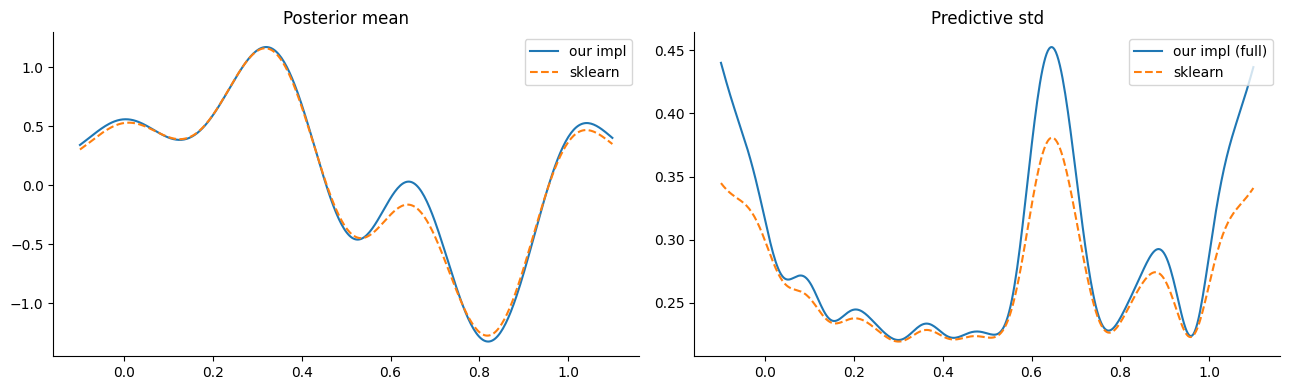

max abs diff in mean: 1.961e-01


In [4]:
br = BayesianRidge(fit_intercept=False, alpha_init=beta, lambda_init=alpha,
                   alpha_1=1e-9, alpha_2=1e-9, lambda_1=1e-9, lambda_2=1e-9,
                   max_iter=1)  # 1 iteration disables hyperparam update so we match our fixed alpha/beta
br.fit(Phi_train, y_train)
mean_sk, std_sk = br.predict(Phi_test, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_test, mean, label="our impl")
axes[0].plot(x_test, mean_sk, "--", label="sklearn")
axes[0].set_title("Posterior mean"); axes[0].legend()

axes[1].plot(x_test, std_full, label="our impl (full)")
axes[1].plot(x_test, std_sk, "--", label="sklearn")
axes[1].set_title("Predictive std"); axes[1].legend()

plt.tight_layout(); plt.show()
print(f"max abs diff in mean: {np.max(np.abs(mean - mean_sk)):.3e}")


(`BayesianRidge` also estimates $\alpha$ and $\beta$ from data by maximising the marginal likelihood — this is the **evidence approximation** covered in Lecture 2.)

## 5. Limiting cases

- $\alpha \to 0$: the prior becomes flat (improper) and $m_N \to (\Phi^\top \Phi)^{-1} \Phi^\top \mathbf{y}$, which is **OLS**.
- $\alpha$ finite, $\beta$ fixed, just the MAP: $w_{\text{MAP}} = m_N$, which equals **ridge regression** with regularisation parameter $\lambda = \alpha / \beta$.
- $\beta \to \infty$: noise vanishes; the posterior collapses around any $w$ that fits the data exactly.

Hence ridge and OLS are not philosophical opponents of Bayesian regression; they are *point summaries* of specific Bayesian posteriors.

## 6. Exercises

**Exercise 2.1.** Show that as $N \to \infty$ with $\alpha, \beta$ fixed, $S_N \to 0$ and $m_N \to w_{\text{MLE}}$, provided $\Phi^\top \Phi$ has full rank.

**Exercise 2.2.** Implement the posterior with the **Woodbury identity**:
$$S_N = \alpha^{-1}I - \alpha^{-1}\Phi^\top(\alpha\beta^{-1} I + \Phi \Phi^\top)^{-1}\Phi \alpha^{-1}.$$
Compare cost for $N \ll M$ (many basis functions) versus the direct $M \times M$ inverse. Which is faster, and when?

**Exercise 2.3 (Sequential).** Bayesian linear regression admits an exact online update. Derive it: given current posterior $(m_n, S_n)$ and a new observation $(\phi_{n+1}, y_{n+1})$, what is $(m_{n+1}, S_{n+1})$?

**Exercise 2.4 (Predictive log-likelihood).** Compute the log predictive density $\log p(y_* \mid \mathcal{D}, x_*)$ on a held-out test set and compare it against the log density assigned by an OLS estimator with a fixed-variance prediction. Which is better calibrated, and by how much?
